<a href="https://colab.research.google.com/github/Yahir-7/Data_Center_GeoPandas/blob/main/Air_Pollution_PM2_5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

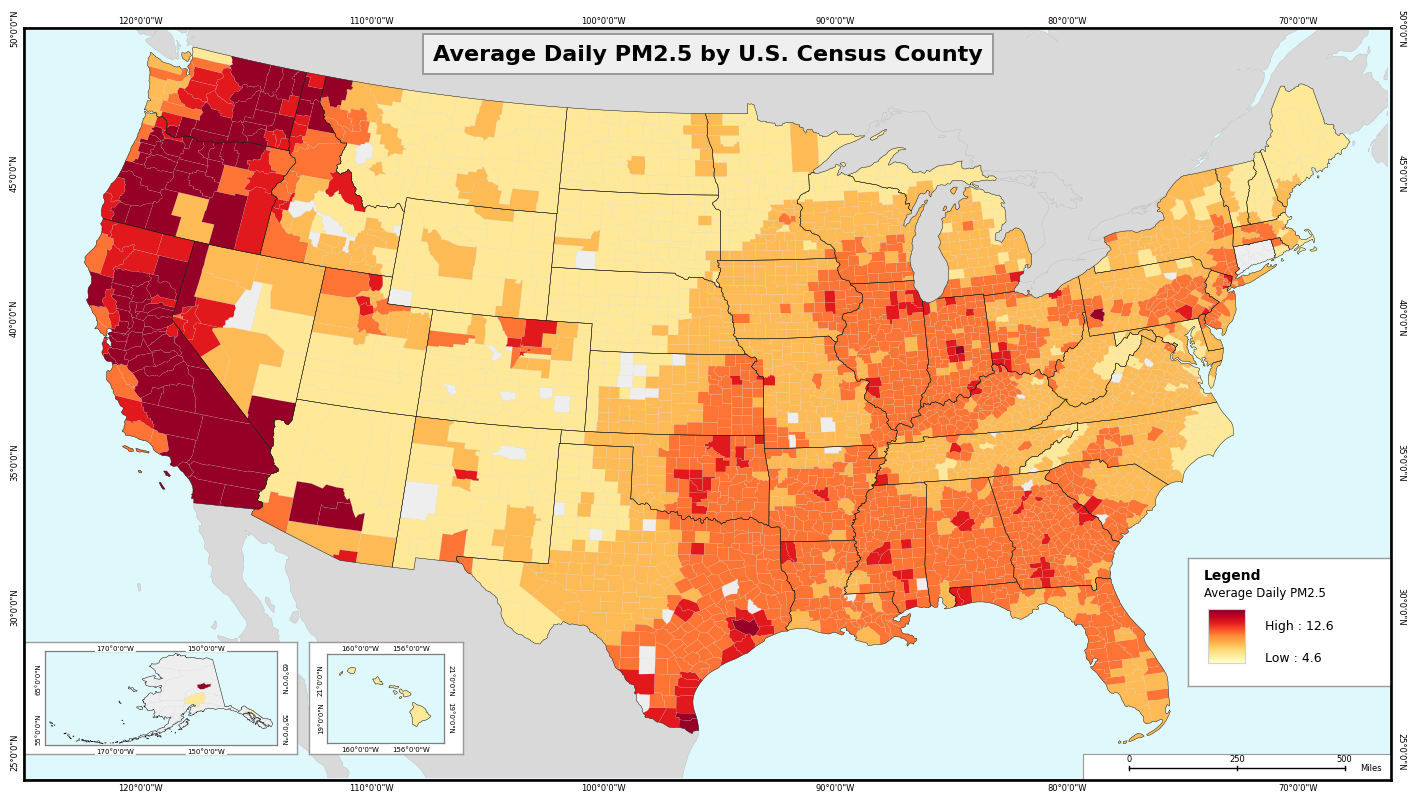

In [1]:
# Run once
# ! pip install numpy geopandas pandas matplotlib openpyxl shapely

import numpy as np
import geopandas as gpd
import pandas as pd
import matplotlib.pyplot as plt

file = "/content/2025 County Health Rankings Data - v4.xlsx"

# Load County Health Rankings data
excel_data = pd.read_excel(
    file,
    sheet_name="Select Measure Data",
    header=1
)

air_pollution = excel_data[[
    "FIPS",
    "State",
    "County",
    "Average Daily PM2.5"
]].copy()

# Keep county rows only
air_pollution = air_pollution[air_pollution["County"].notna()].copy()

# Clean FIPS and PM2.5 column
air_pollution["FIPS"] = air_pollution["FIPS"].astype(int).astype(str).str.zfill(5)

air_pollution["Average Daily PM2.5"] = pd.to_numeric(
    air_pollution["Average Daily PM2.5"],
    errors="coerce"
)

# Load county shapefile from U.S. Census Bureau
counties = gpd.read_file(
    "https://www2.census.gov/geo/tiger/GENZ2023/shp/cb_2023_us_county_20m.zip"
)

counties = counties.to_crs(epsg=4326)

# Merge county map with PM2.5 data
merged = counties.merge(
    air_pollution,
    left_on="GEOID",
    right_on="FIPS",
    how="left"
)

# Remove U.S. territories only
territory_codes = ["60", "66", "69", "72", "78"]
merged = merged[~merged["STATEFP"].isin(territory_codes)].copy()

# Color scale
pm_values = merged["Average Daily PM2.5"].dropna()
vmin = pm_values.quantile(0.02)
vmax = pm_values.quantile(0.98)

# Create PM2.5 range bins for the map
bins = np.linspace(vmin, vmax, 6)

merged["pm_bin"] = pd.cut(
    merged["Average Daily PM2.5"],
    bins=bins,
    labels=False,
    include_lowest=True
)

# Put out-of-range values into first/last bins
merged.loc[merged["Average Daily PM2.5"] < vmin, "pm_bin"] = 0
merged.loc[merged["Average Daily PM2.5"] > vmax, "pm_bin"] = 4

# Split into maps
lower48 = merged[~merged["STATEFP"].isin(["02", "15"])].copy()
alaska = merged[merged["STATEFP"] == "02"].copy()
hawaii = merged[merged["STATEFP"] == "15"].copy()

# Projections
lower48_proj = lower48.to_crs(epsg=5070)
alaska_proj = alaska.to_crs(epsg=3338)
hawaii_proj = hawaii.to_crs(epsg=4326)

# Load neighboring countries (Canada and Mexico) for background context, shown greyed out
world_url = "https://naciscdn.org/naturalearth/50m/cultural/ne_50m_admin_0_countries.zip"
world = gpd.read_file(world_url)
world = world.to_crs(epsg=4326)

neighbor_names = ["Canada", "Mexico"]
neighbors = world[world["ADMIN"].isin(neighbor_names)].copy()
neighbors_proj = neighbors.to_crs(epsg=5070)

# Load major lakes (Great Lakes, etc.) for background context, shown greyed out
# just like Canada and Mexico
lakes_url = "https://naciscdn.org/naturalearth/50m/physical/ne_50m_lakes.zip"
lakes = gpd.read_file(lakes_url)
lakes = lakes.to_crs(epsg=4326)

great_lakes_names = [
    "Lake Superior",
    "Lake Michigan",
    "Lake Huron",
    "Lake Erie",
    "Lake Ontario"
]
great_lakes = lakes[lakes["name"].isin(great_lakes_names)].copy()
great_lakes_proj = great_lakes.to_crs(epsg=5070)

# Create state boundary layers
lower48_states = lower48_proj.dissolve(by="STATEFP")
alaska_states = alaska_proj.dissolve(by="STATEFP")
hawaii_states = hawaii_proj.dissolve(by="STATEFP")

# Colors for PM2.5 bins
colors = plt.cm.YlOrRd(np.linspace(0.15, 0.95, 5))
missing_color = "#eeeeee"

# Plot each PM2.5 bin safely
def plot_pm_map(ax, gdf, linewidth):
    missing = gdf[gdf["pm_bin"].isna()]

    if not missing.empty:
        missing.plot(
            color=missing_color,
            edgecolor="lightgray",
            linewidth=linewidth,
            ax=ax,
            zorder=2
        )

    for i in range(5):
        bin_df = gdf[gdf["pm_bin"] == i]

        if not bin_df.empty:
            bin_df.plot(
                color=colors[i],
                edgecolor="lightgray",
                linewidth=linewidth,
                ax=ax,
                zorder=3
            )

# Convert decimal degrees to degree-minute-second format
def decimal_to_dms(value, is_lon=True):
    if is_lon:
        direction = "W" if value < 0 else "E"
    else:
        direction = "S" if value < 0 else "N"

    value = abs(value)
    degrees = int(value)
    minutes_float = (value - degrees) * 60
    minutes = int(minutes_float)
    seconds = int(round((minutes_float - minutes) * 60))

    if seconds == 60:
        seconds = 0
        minutes += 1

    if minutes == 60:
        minutes = 0
        degrees += 1

    return f"{degrees}°{minutes}'{seconds}\"{direction}"

# Add DMS labels only, without grid lines.
# Set on_line=True to have the labels straddle the border line itself
# (centered on the line, half in / half out) instead of sitting just
# outside the box.
def add_dms_frame_labels(
    ax,
    lon_values,
    lat_values,
    lon_min,
    lon_max,
    lat_min,
    lat_max,
    lon_fontsize=6,
    lat_fontsize=6,
    on_line=False,
    top_inset=0.0,
    bottom_inset=0.0,
    left_inset=0.0,
    right_inset=0.0
):
    if on_line:
        top_y, bottom_y = 1.0 - top_inset, 0.0 + bottom_inset
        va_top, va_bottom = "center", "center"
        left_x, right_x = 0.0 + left_inset, 1.0 - right_inset
        ha_left, ha_right = "center", "center"
        label_bbox = dict(
            facecolor="white",
            edgecolor="none",
            pad=1.0
        )
    else:
        top_y, bottom_y = 1.004, -0.004
        va_top, va_bottom = "bottom", "top"
        left_x, right_x = -0.004, 1.004
        ha_left, ha_right = "right", "left"
        label_bbox = None

    for lon in lon_values:
        x_frac = (lon - lon_min) / (lon_max - lon_min)
        label = decimal_to_dms(lon, is_lon=True)

        ax.text(
            x_frac,
            top_y,
            label,
            transform=ax.transAxes,
            ha="center",
            va=va_top,
            fontsize=lon_fontsize,
            color="black",
            clip_on=False,
            bbox=label_bbox,
            zorder=30
        )

        ax.text(
            x_frac,
            bottom_y,
            label,
            transform=ax.transAxes,
            ha="center",
            va=va_bottom,
            fontsize=lon_fontsize,
            color="black",
            clip_on=False,
            bbox=label_bbox,
            zorder=30
        )

    for lat in lat_values:
        y_frac = (lat - lat_min) / (lat_max - lat_min)
        label = decimal_to_dms(lat, is_lon=False)

        ax.text(
            left_x,
            y_frac,
            label,
            transform=ax.transAxes,
            ha=ha_left,
            va="center",
            rotation=90,
            fontsize=lat_fontsize,
            color="black",
            clip_on=False,
            bbox=label_bbox,
            zorder=30
        )

        ax.text(
            right_x,
            y_frac,
            label,
            transform=ax.transAxes,
            ha=ha_right,
            va="center",
            rotation=270,
            fontsize=lat_fontsize,
            color="black",
            clip_on=False,
            bbox=label_bbox,
            zorder=30
        )

# Add coordinate labels directly on top of or below an inset map (inside the box)
def add_inset_edge_labels(ax, values, value_min, value_max, is_lon=True, fontsize=4.5, color="black", position="top"):
    n = len(values)
    y_pos = 0.96 if position == "top" else 0.04
    va = "top" if position == "top" else "bottom"

    for i, value in enumerate(values):
        x_frac = (value - value_min) / (value_max - value_min)
        label = decimal_to_dms(value, is_lon=is_lon)

        if i == 0:
            ha = "left"
            x_pos = 0.02
        elif i == n - 1:
            ha = "right"
            x_pos = 0.98
        else:
            ha = "center"
            x_pos = x_frac

        ax.text(
            x_pos,
            y_pos,
            label,
            transform=ax.transAxes,
            ha=ha,
            va=va,
            fontsize=fontsize,
            fontweight="bold",
            color=color,
            zorder=25
        )

# Draw a simple visual scale bar in its own small box
def draw_scale_box(ax, labels=("0", "250", "500"), unit="Miles"):
    ax.set_facecolor("white")

    for spine in ax.spines.values():
        spine.set_visible(True)
        spine.set_linewidth(0.8)
        spine.set_edgecolor("#9a9a9a")

    ax.set_xticks([])
    ax.set_yticks([])

    # Main scale line
    ax.plot([0.15, 0.85], [0.45, 0.45], color="black", linewidth=1.0)

    # Tick marks
    ax.plot([0.15, 0.15], [0.38, 0.52], color="black", linewidth=1.0)
    ax.plot([0.50, 0.50], [0.38, 0.52], color="black", linewidth=1.0)
    ax.plot([0.85, 0.85], [0.38, 0.52], color="black", linewidth=1.0)

    # Labels
    ax.text(0.15, 0.62, labels[0], ha="center", va="bottom", fontsize=6)
    ax.text(0.50, 0.62, labels[1], ha="center", va="bottom", fontsize=6)
    ax.text(0.85, 0.62, labels[2], ha="center", va="bottom", fontsize=6)
    ax.text(0.90, 0.45, unit, ha="left", va="center", fontsize=6)

    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)

# Figure layout
fig = plt.figure(figsize=(14, 8), facecolor="white")

# Background frame that fills almost the entire figure.
ax_frame_bg = fig.add_axes([0.012, 0.030, 0.976, 0.940], zorder=0)
ax_frame_bg.set_facecolor("#dff8fb")

for spine in ax_frame_bg.spines.values():
    spine.set_visible(True)
    spine.set_linewidth(1.2)
    spine.set_edgecolor("#7f7f7f")

ax_frame_bg.set_xticks([])
ax_frame_bg.set_yticks([])

# Main lower 48 map — box nearly matches ax_frame_bg, same as the
# Percent of Children Under 18 map, so the map itself takes up
# virtually the whole frame.
ax_main = fig.add_axes([0.014, 0.032, 0.972, 0.936], zorder=2)
ax_main.set_facecolor("#dff8fb")

# Plot Canada and Mexico as greyed-out background context
neighbors_proj.plot(
    ax=ax_main,
    color="#d9d9d9",
    edgecolor="#bcbcbc",
    linewidth=0.3,
    zorder=1
)

# Plot the Great Lakes as greyed-out background context, same style as Canada/Mexico
great_lakes_proj.plot(
    ax=ax_main,
    color="#d9d9d9",
    edgecolor="#bcbcbc",
    linewidth=0.3,
    zorder=1
)

# Plot PM2.5 map
plot_pm_map(ax_main, lower48_proj, 0.08)

# Thin black state borders
lower48_states.boundary.plot(
    ax=ax_main,
    color="black",
    linewidth=0.30,
    zorder=4
)

# Buffer tuned to match the reference map's proportions, same values as
# the Percent of Children Under 18 map.
minx, miny, maxx, maxy = lower48_proj.total_bounds
x_buffer_left = (maxx - minx) * 0.045
x_buffer_right = (maxx - minx) * 0.030
y_buffer_top = (maxy - miny) * 0.025
y_buffer_bottom = (maxy - miny) * 0.050

ax_main.set_xlim(minx - x_buffer_left, maxx + x_buffer_right)
ax_main.set_ylim(miny - y_buffer_bottom, maxy + y_buffer_top)

# Stretch the map
ax_main.set_aspect("auto")

# Remove the inner main-map border so only the big outer border shows
for spine in ax_main.spines.values():
    spine.set_visible(False)

ax_main.set_xticks([])
ax_main.set_yticks([])

# Alaska outer white box
ak_outer = fig.add_axes([0.012, 0.062, 0.195, 0.140], zorder=4)
ak_outer.set_facecolor("white")

for spine in ak_outer.spines.values():
    spine.set_visible(True)
    spine.set_linewidth(1.0)
    spine.set_edgecolor("#9a9a9a")

ak_outer.set_xticks([])
ak_outer.set_yticks([])

# Alaska inner map box
ak_inner_left = 0.075
ak_inner_bottom = 0.080
ak_inner_width = 0.850
ak_inner_height = 0.840

ax_ak = ak_outer.inset_axes([
    ak_inner_left,
    ak_inner_bottom,
    ak_inner_width,
    ak_inner_height
])

ax_ak.set_facecolor("#dff8fb")

plot_pm_map(ax_ak, alaska_proj, 0.10)

alaska_states.boundary.plot(
    ax=ax_ak,
    color="black",
    linewidth=0.32,
    zorder=4
)

minx, miny, maxx, maxy = alaska_proj.total_bounds
x_buffer = (maxx - minx) * 0.02
y_buffer = (maxy - miny) * 0.02

ax_ak.set_xlim(minx - x_buffer, maxx + x_buffer)
ax_ak.set_ylim(miny - y_buffer, maxy + y_buffer)

# Stretch to completely fill the inset box
ax_ak.set_aspect("auto")

for spine in ax_ak.spines.values():
    spine.set_visible(True)
    spine.set_linewidth(0.9)
    spine.set_edgecolor("#7f7f7f")

ax_ak.set_xticks([])
ax_ak.set_yticks([])

# Alaska longitude + latitude labels
add_dms_frame_labels(
    ax=ak_outer,
    lon_values=[-170, -150],
    lat_values=[55, 65],
    lon_min=-190,
    lon_max=-130,
    lat_min=50,
    lat_max=72,
    lon_fontsize=5,
    lat_fontsize=5,
    on_line=True,
    top_inset=0.05,
    bottom_inset=0.03,
    left_inset=0.05,
    right_inset=0.05
)

# Hawaii outer white box
hi_outer = fig.add_axes([0.215, 0.062, 0.11, 0.140], zorder=4)
hi_outer.set_facecolor("white")

for spine in hi_outer.spines.values():
    spine.set_visible(True)
    spine.set_linewidth(1.0)
    spine.set_edgecolor("#9a9a9a")

hi_outer.set_xticks([])
hi_outer.set_yticks([])

# Hawaii inner map box
hi_inner_left = 0.045
hi_inner_bottom = 0.100
hi_inner_width = 0.910
hi_inner_height = 0.800

ax_hi = hi_outer.inset_axes([
    hi_inner_left,
    hi_inner_bottom,
    hi_inner_width,
    hi_inner_height
])

ax_hi.set_facecolor("#dff8fb")

plot_pm_map(ax_hi, hawaii_proj, 0.10)

hawaii_states.boundary.plot(
    ax=ax_hi,
    color="black",
    linewidth=0.32,
    zorder=4
)

ax_hi.set_xlim(-161, -154)
ax_hi.set_ylim(18, 23)

for spine in ax_hi.spines.values():
    spine.set_visible(True)
    spine.set_linewidth(0.9)
    spine.set_edgecolor("#7f7f7f")

ax_hi.set_xticks([])
ax_hi.set_yticks([])

# Hawaii longitude + latitude labels
add_dms_frame_labels(
    ax=hi_outer,
    lon_values=[-160, -156],
    lat_values=[19, 21],
    lon_min=-164,
    lon_max=-152,
    lat_min=17,
    lat_max=23,
    lon_fontsize=5,
    lat_fontsize=5,
    on_line=True,
    top_inset=0.05,
    bottom_inset=0.05,
    left_inset=0.08,
    right_inset=0.08
)

# Scale bar in bottom-right corner
ax_scale = fig.add_axes([0.768, 0.030, 0.220, 0.033], zorder=4)
draw_scale_box(ax_scale, labels=("0", "250", "500"), unit="Miles")

# Legend box
ax_leg = fig.add_axes([0.843, 0.148, 0.145, 0.160], zorder=4)
ax_leg.set_facecolor("white")

for spine in ax_leg.spines.values():
    spine.set_visible(True)
    spine.set_linewidth(1.0)
    spine.set_edgecolor("#9a9a9a")

ax_leg.set_xticks([])
ax_leg.set_yticks([])

# Legend title
ax_leg.text(
    0.08,
    0.92,
    "Legend",
    fontsize=10,
    fontweight="bold",
    ha="left",
    va="top"
)

ax_leg.text(
    0.08,
    0.78,
    "Average Daily PM2.5",
    fontsize=8.5,
    ha="left",
    va="top"
)

# Gradient color scale inside legend
scale_ax = ax_leg.inset_axes([0.10, 0.18, 0.18, 0.42])

gradient = np.linspace(vmax, vmin, 256).reshape(256, 1)

scale_ax.imshow(
    gradient,
    aspect="auto",
    cmap="YlOrRd"
)

scale_ax.set_xticks([])
scale_ax.set_yticks([])

for spine in scale_ax.spines.values():
    spine.set_visible(True)
    spine.set_linewidth(0.8)
    spine.set_edgecolor("lightgray")

# High / Low labels
ax_leg.text(
    0.38,
    0.47,
    f"High : {vmax:.1f}",
    fontsize=9,
    ha="left",
    va="center"
)

ax_leg.text(
    0.38,
    0.22,
    f"Low : {vmin:.1f}",
    fontsize=9,
    ha="left",
    va="center"
)

# Transparent top frame for border, coordinate labels, and title.
# Matches ax_frame_bg exactly so the border lines up with the edge of
# the (now much larger) blue map area.
ax_frame = fig.add_axes([0.012, 0.030, 0.976, 0.940], zorder=10)
ax_frame.patch.set_alpha(0)

for spine in ax_frame.spines.values():
    spine.set_visible(True)
    spine.set_linewidth(1.9)
    spine.set_edgecolor("black")

ax_frame.set_xticks([])
ax_frame.set_yticks([])

# DMS coordinate labels around the whole map layout
add_dms_frame_labels(
    ax=ax_frame,
    lon_values=[-120, -110, -100, -90, -80, -70],
    lat_values=[25, 30, 35, 40, 45, 50],
    lon_min=-125,
    lon_max=-66,
    lat_min=24,
    lat_max=50,
    lon_fontsize=6,
    lat_fontsize=6
)

# Title inside the big frame
ax_frame.text(
    0.5,
    0.965,
    "Average Daily PM2.5 by U.S. Census County",
    transform=ax_frame.transAxes,
    ha="center",
    va="center",
    fontsize=16,
    fontweight="bold",
    bbox=dict(
        facecolor="#efefef",
        edgecolor="#9a9a9a",
        boxstyle="square,pad=0.45",
        linewidth=1.4
    ),
    zorder=20
)

plt.show()